<a href="https://www.kaggle.com/code/omborse771924/women-s-e-commerce-clothing-reviews-sales-eda?scriptVersionId=341990795" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/razanihababdellatif/womens-e-commerce-clothing-reviews-and-sales/women_clothing_50k.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/womens-e-commerce-clothing-reviews-and-sales/women_clothing_50k.csv')

In [3]:
df.head()

,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
0,WC000001,Jeans,Skinny Jeans,Denim,Red,M,Summer,Business Casual,37.00,0,0.0,0,2,14,0.17
1,WC000002,Dresses,Wrap Dress,Cotton,White,M,Winter,Casual,59.12,10,0.0,0,13,31,0.13
2,WC000003,T-Shirts,V-Neck T-Shirt,Cotton,Purple,M,All Season,Casual,27.65,0,0.0,0,10,2,0.11
3,WC000004,Sweaters,Oversized Sweater,Wool,Brown,S,Winter,Formal,72.64,0,2.9,17,104,292,0.14
4,WC000005,Sweaters,Oversized Sweater,Wool,White,M,Winter,Minimalist,72.61,40,0.0,0,12,15,0.07


In [4]:
df.tail()

,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
49995,WC049996,Coats,Long Coat,Cotton,Black,L,Winter,Business Casual,67.13,10,3.7,1,54,23,0.12
49996,WC049997,Dresses,Midi Dress,Cotton Blend,White,M,Spring,Bohemian,81.27,20,4.3,2,154,52,0.14
49997,WC049998,Jeans,Wide-Leg Jeans,Cotton Blend,Red,L,Autumn,Minimalist,60.96,20,5.0,1,12,84,0.16
49998,WC049999,Sweaters,Knit Sweater,Wool,Beige,L,Autumn,Bohemian,79.54,20,4.4,2,4,140,0.08
49999,WC050000,Tops,Long Sleeve Top,Viscose,White,M,Winter,Elegant,19.72,0,0.0,0,29,6,0.06


In [5]:
df.info

<bound method DataFrame.info of       product_id  category        subcategory      material   color size  \
0       WC000001     Jeans       Skinny Jeans         Denim     Red    M   
1       WC000002   Dresses         Wrap Dress        Cotton   White    M   
2       WC000003  T-Shirts     V-Neck T-Shirt        Cotton  Purple    M   
3       WC000004  Sweaters  Oversized Sweater          Wool   Brown    S   
4       WC000005  Sweaters  Oversized Sweater          Wool   White    M   
...          ...       ...                ...           ...     ...  ...   
49995   WC049996     Coats          Long Coat        Cotton   Black    L   
49996   WC049997   Dresses         Midi Dress  Cotton Blend   White    M   
49997   WC049998     Jeans     Wide-Leg Jeans  Cotton Blend     Red    L   
49998   WC049999  Sweaters       Knit Sweater          Wool   Beige    L   
49999   WC050000      Tops    Long Sleeve Top       Viscose   White    M   

           season            style  price_usd  discount

In [6]:
df.describe

<bound method NDFrame.describe of       product_id  category        subcategory      material   color size  \
0       WC000001     Jeans       Skinny Jeans         Denim     Red    M   
1       WC000002   Dresses         Wrap Dress        Cotton   White    M   
2       WC000003  T-Shirts     V-Neck T-Shirt        Cotton  Purple    M   
3       WC000004  Sweaters  Oversized Sweater          Wool   Brown    S   
4       WC000005  Sweaters  Oversized Sweater          Wool   White    M   
...          ...       ...                ...           ...     ...  ...   
49995   WC049996     Coats          Long Coat        Cotton   Black    L   
49996   WC049997   Dresses         Midi Dress  Cotton Blend   White    M   
49997   WC049998     Jeans     Wide-Leg Jeans  Cotton Blend     Red    L   
49998   WC049999  Sweaters       Knit Sweater          Wool   Beige    L   
49999   WC050000      Tops    Long Sleeve Top       Viscose   White    M   

           season            style  price_usd  discou

In [7]:
df.isnull

<bound method DataFrame.isnull of       product_id  category        subcategory      material   color size  \
0       WC000001     Jeans       Skinny Jeans         Denim     Red    M   
1       WC000002   Dresses         Wrap Dress        Cotton   White    M   
2       WC000003  T-Shirts     V-Neck T-Shirt        Cotton  Purple    M   
3       WC000004  Sweaters  Oversized Sweater          Wool   Brown    S   
4       WC000005  Sweaters  Oversized Sweater          Wool   White    M   
...          ...       ...                ...           ...     ...  ...   
49995   WC049996     Coats          Long Coat        Cotton   Black    L   
49996   WC049997   Dresses         Midi Dress  Cotton Blend   White    M   
49997   WC049998     Jeans     Wide-Leg Jeans  Cotton Blend     Red    L   
49998   WC049999  Sweaters       Knit Sweater          Wool   Beige    L   
49999   WC050000      Tops    Long Sleeve Top       Viscose   White    M   

           season            style  price_usd  discou

In [8]:
df.isnull().sum()

product_id          0
category            0
subcategory         0
material            0
color               0
size                0
season              0
style               0
price_usd           0
discount_percent    0
rating              0
review_count        0
stock_quantity      0
units_sold          0
return_rate         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['product_id', 'category', 'subcategory', 'material', 'color', 'size',
       'season', 'style', 'price_usd', 'discount_percent', 'rating',
       'review_count', 'stock_quantity', 'units_sold', 'return_rate'],
      dtype='object')

## EDA

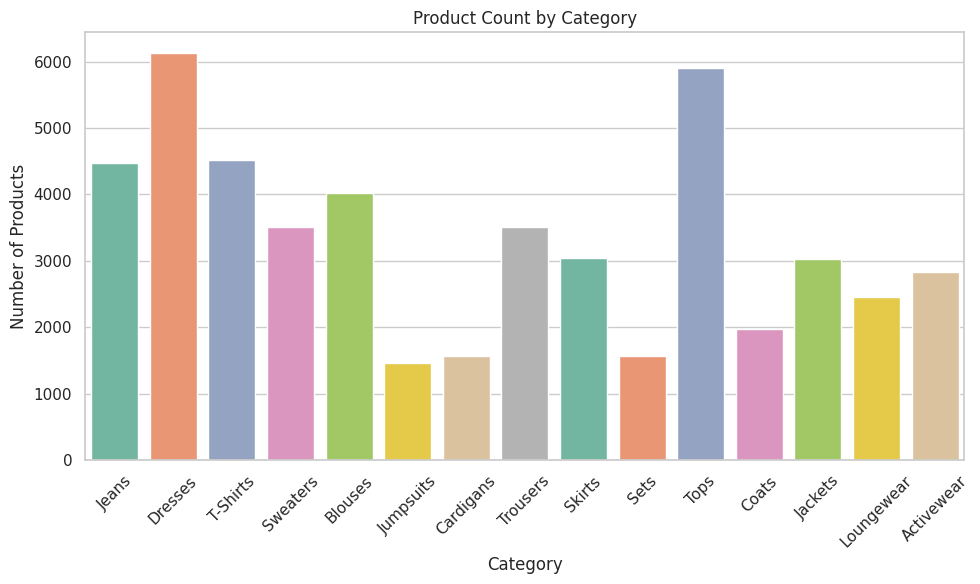

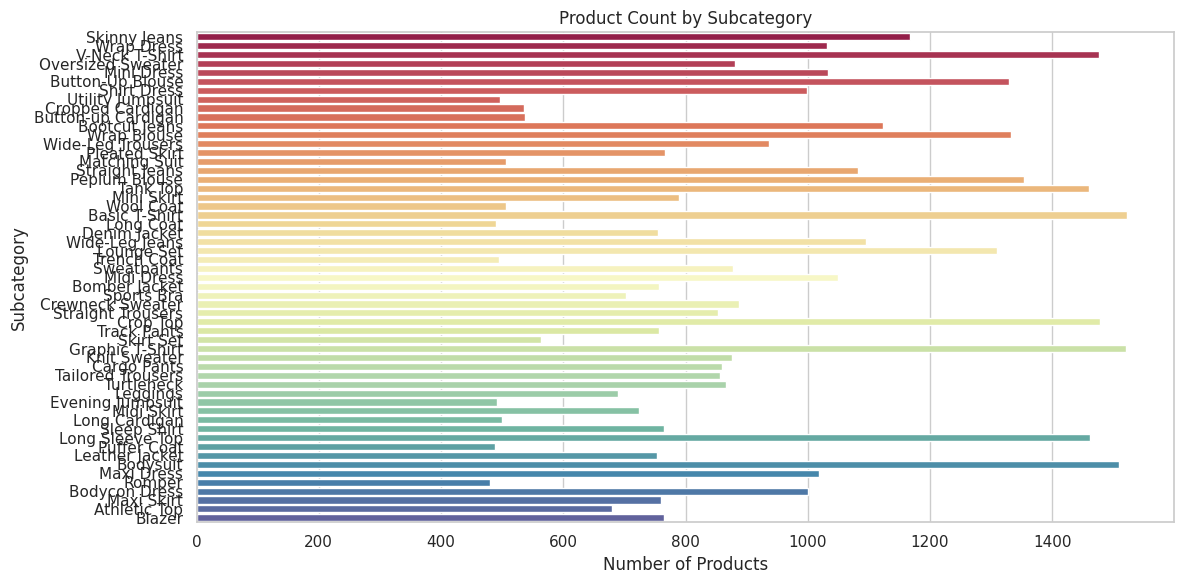

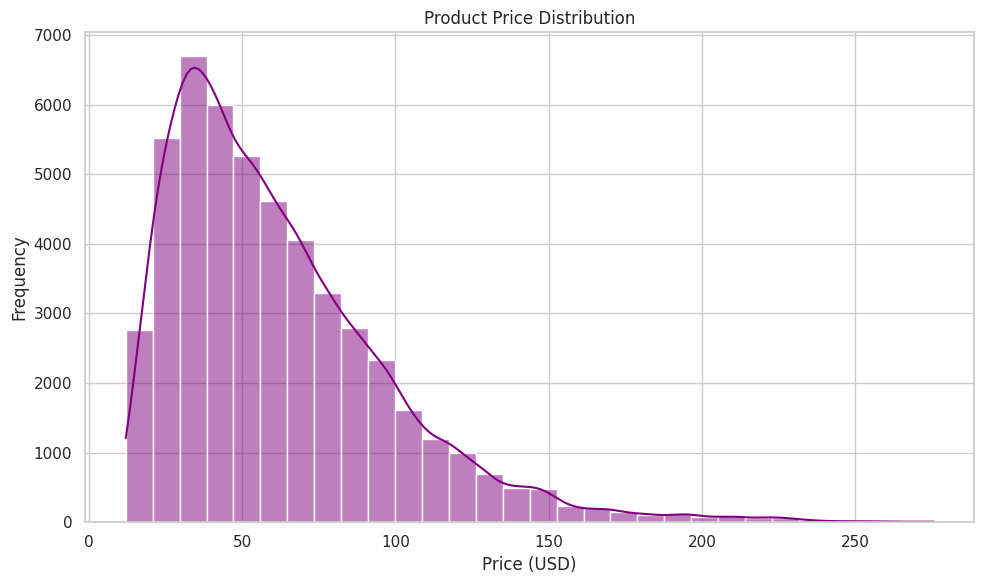

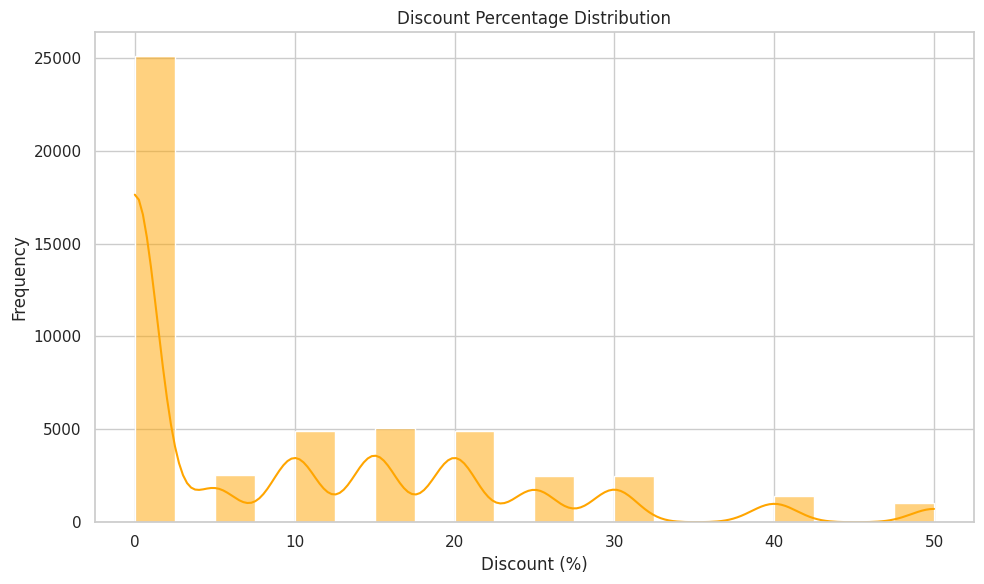

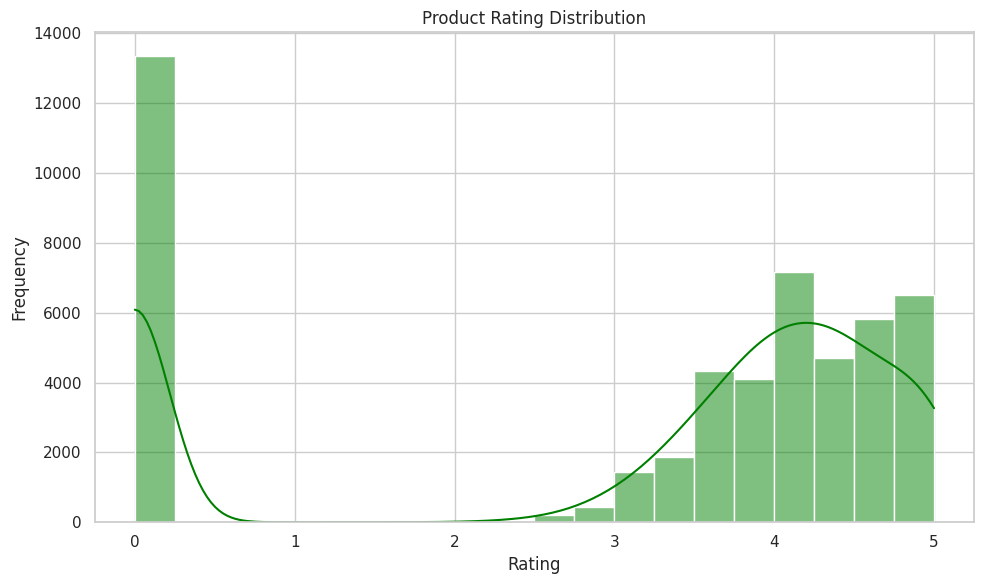

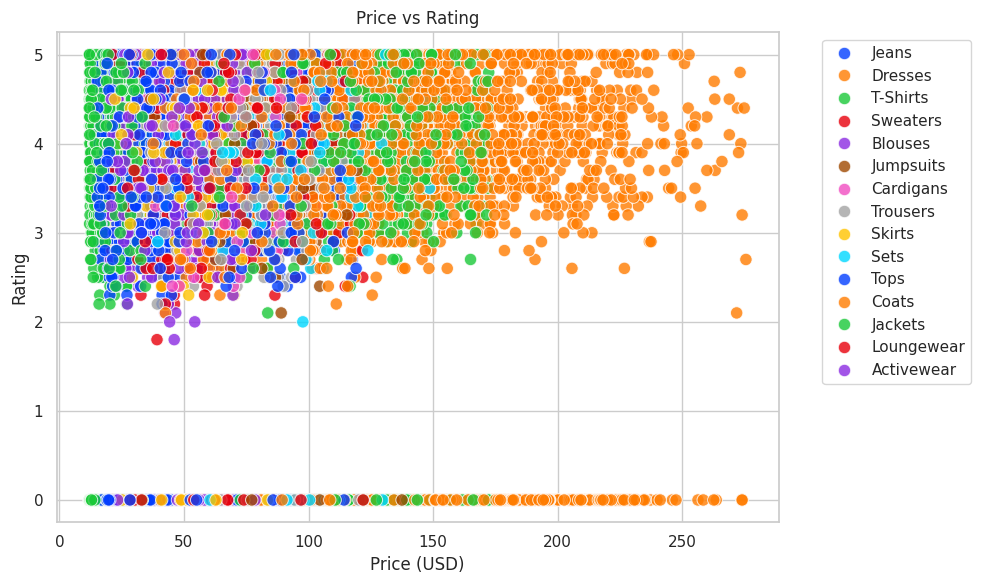

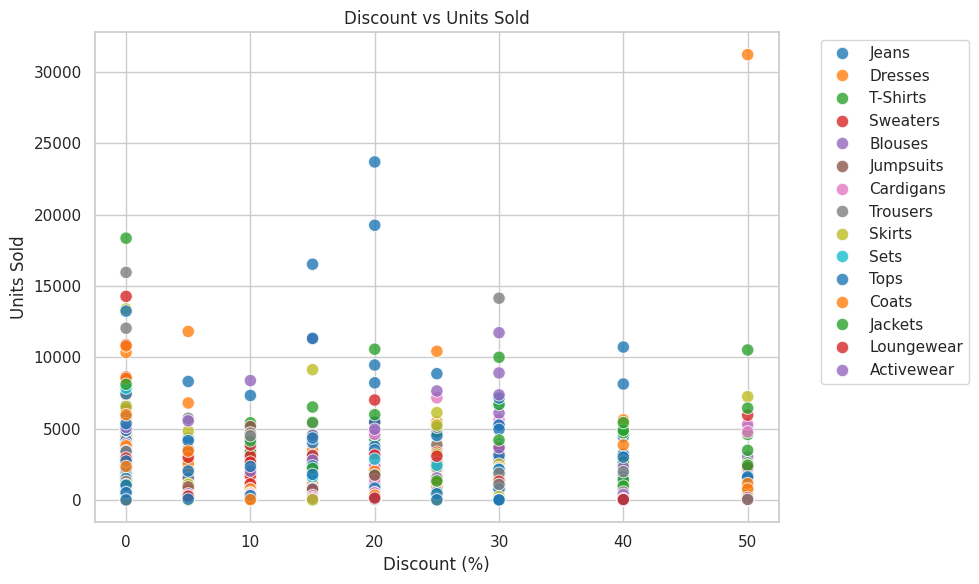

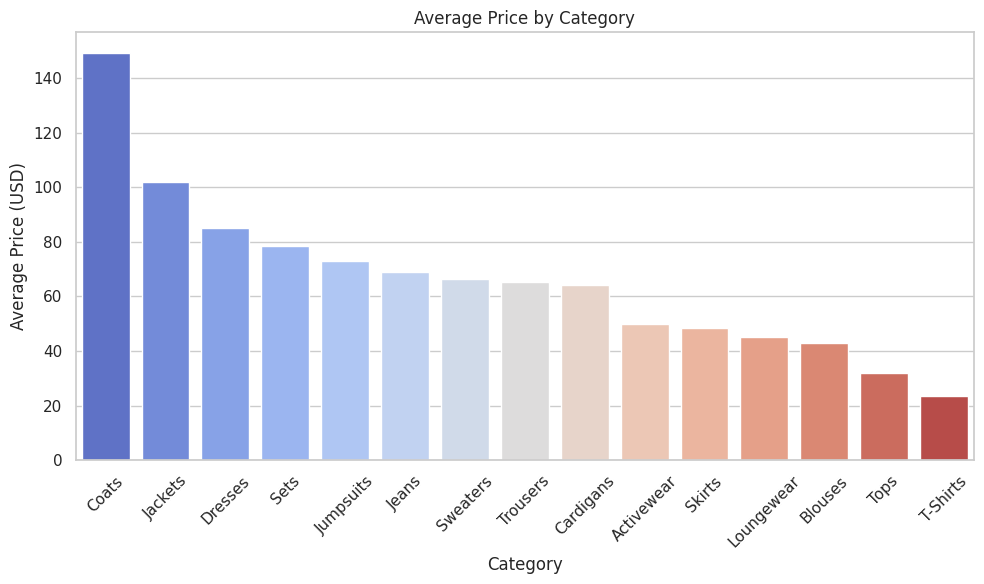

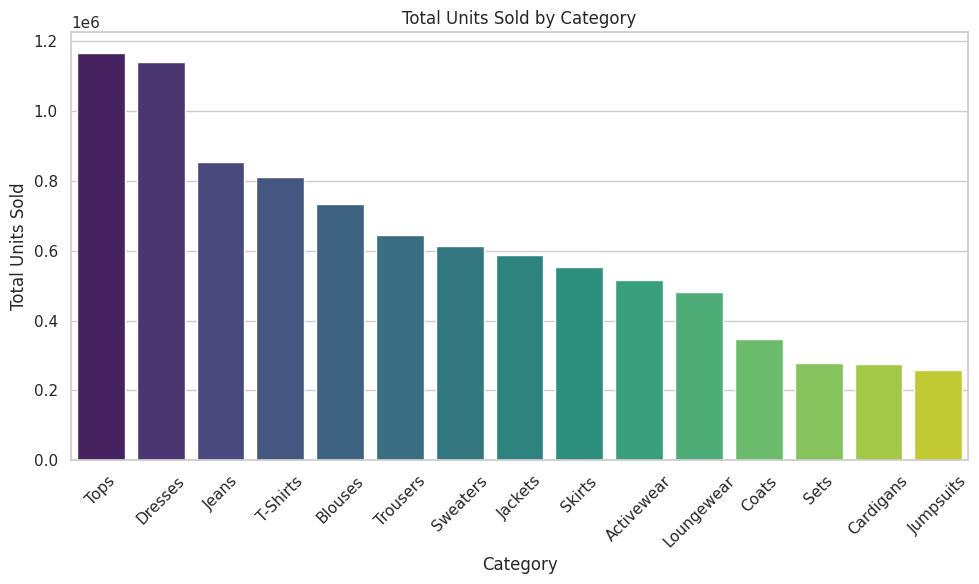

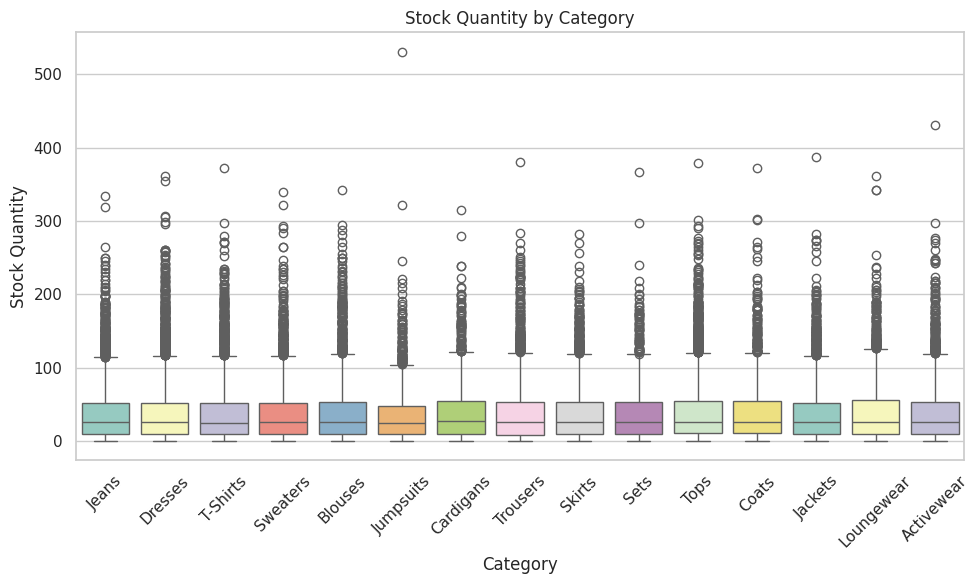

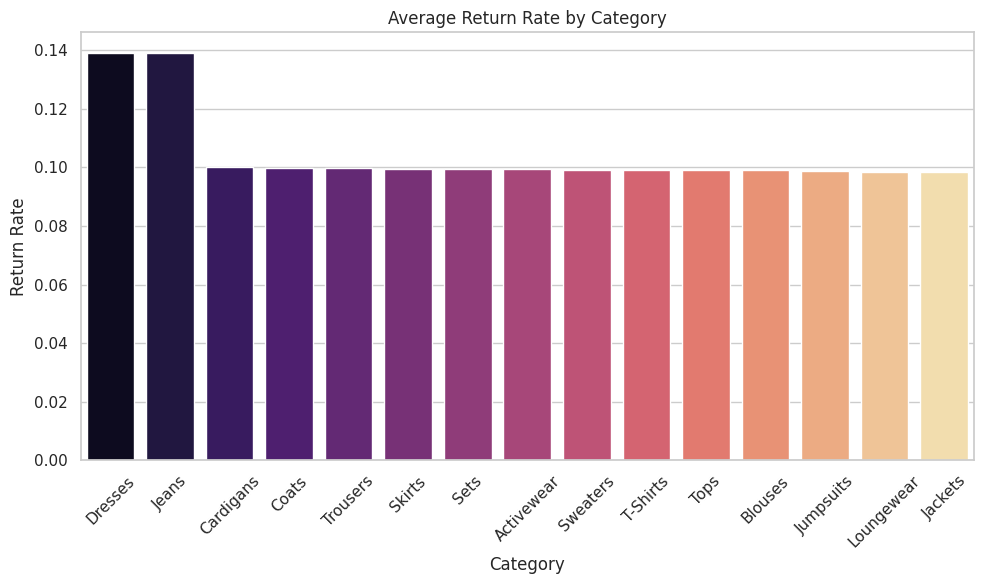

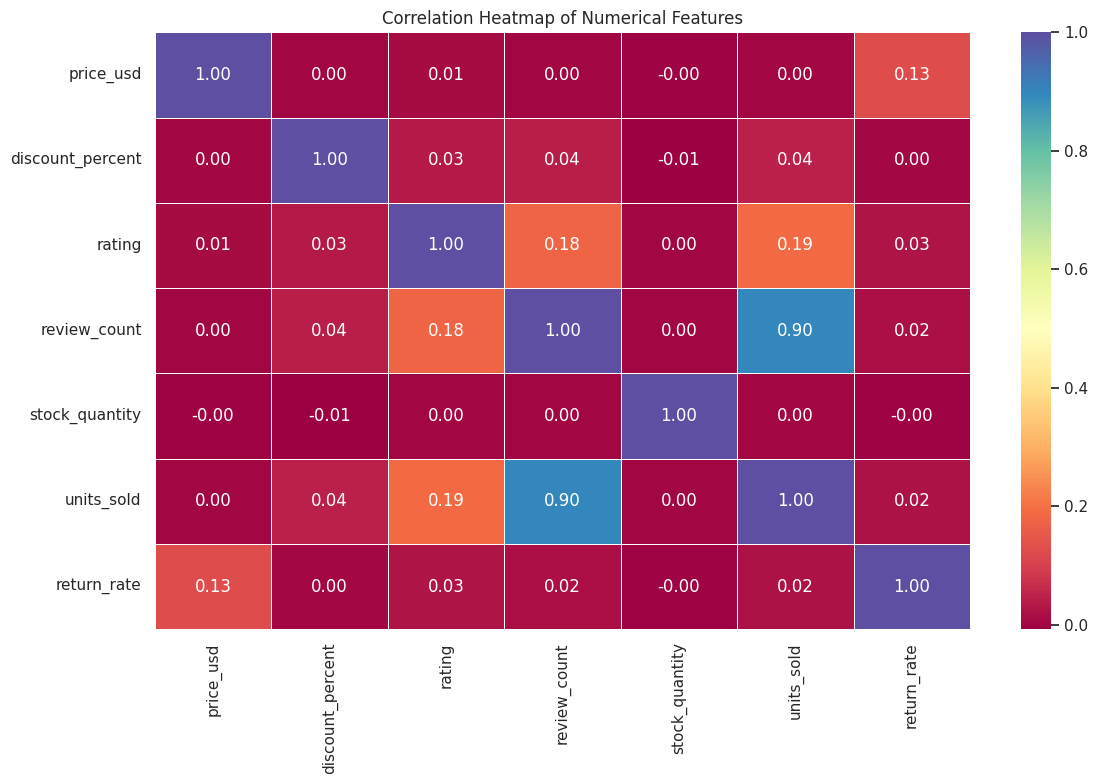

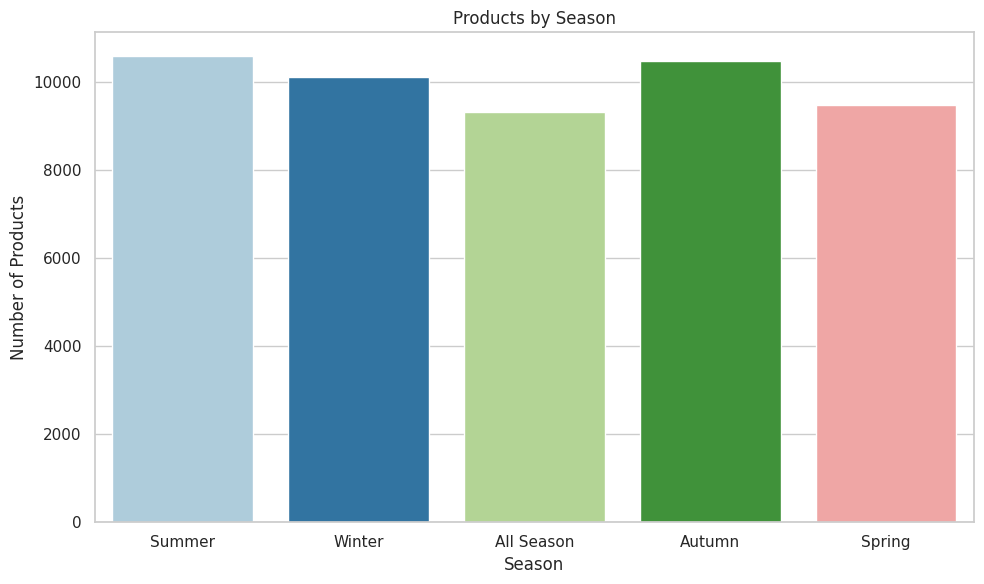

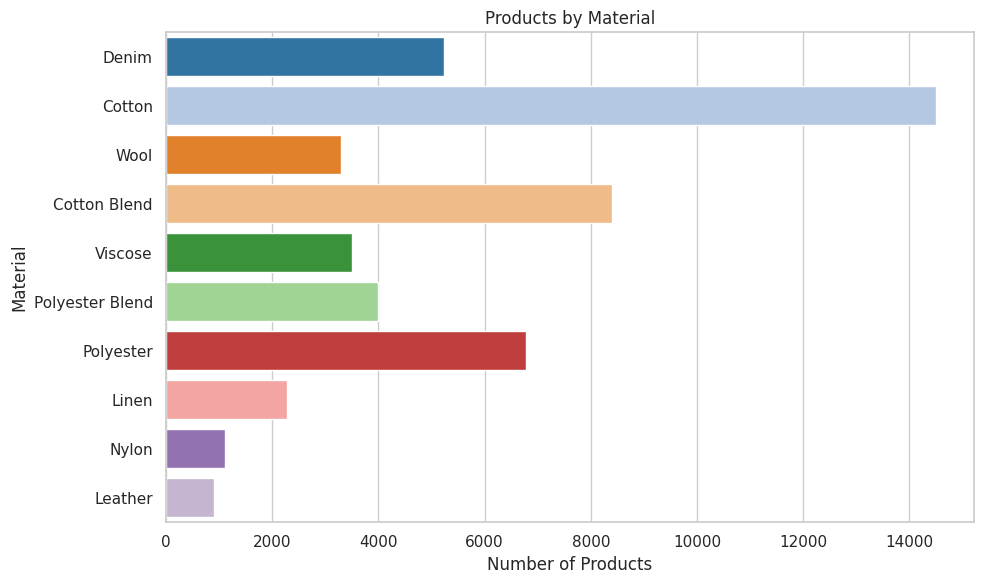

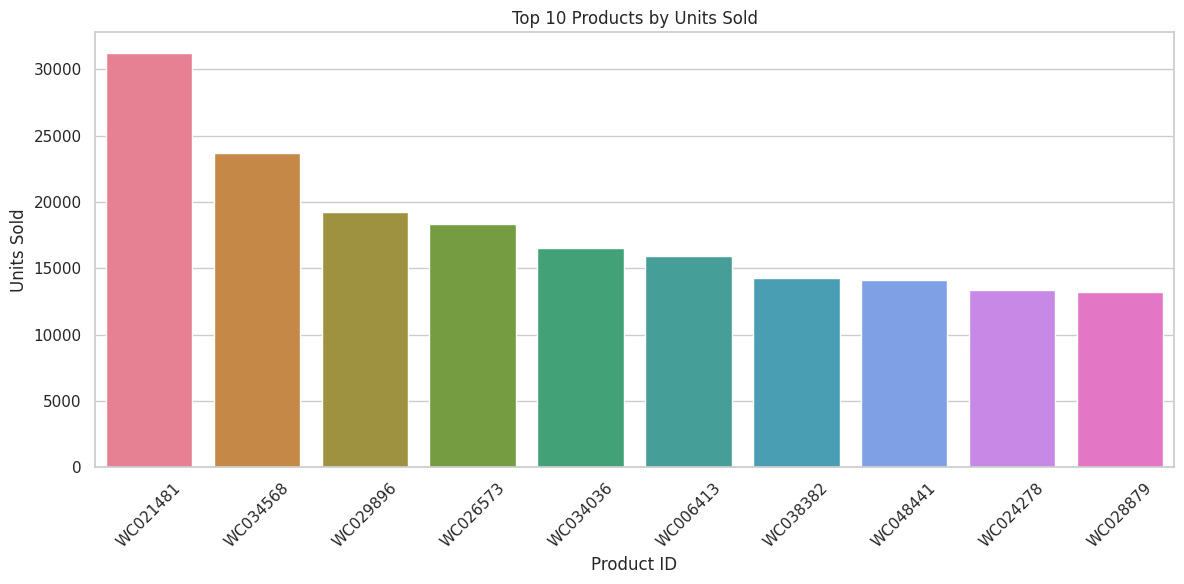

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Set colorful style
sns.set_theme(style="whitegrid", palette="husl")

# =========================================================
# 1. Category Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="category",
    hue="category",
    palette="Set2",
    legend=False
)
plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 2. Subcategory Distribution
# =========================================================
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    y="subcategory",
    hue="subcategory",
    palette="Spectral",
    legend=False
)
plt.title("Product Count by Subcategory")
plt.xlabel("Number of Products")
plt.ylabel("Subcategory")
plt.tight_layout()
plt.show()


# =========================================================
# 3. Price Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    df["price_usd"],
    bins=30,
    kde=True,
    color="purple"
)
plt.title("Product Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# =========================================================
# 4. Discount Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    df["discount_percent"],
    bins=20,
    kde=True,
    color="orange"
)
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# =========================================================
# 5. Rating Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    df["rating"],
    bins=20,
    kde=True,
    color="green"
)
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# =========================================================
# 6. Price vs Rating
# =========================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="price_usd",
    y="rating",
    hue="category",
    palette="bright",
    s=80,
    alpha=0.8
)
plt.title("Price vs Rating")
plt.xlabel("Price (USD)")
plt.ylabel("Rating")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# =========================================================
# 7. Discount vs Units Sold
# =========================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="discount_percent",
    y="units_sold",
    hue="category",
    palette="tab10",
    s=80,
    alpha=0.8
)
plt.title("Discount vs Units Sold")
plt.xlabel("Discount (%)")
plt.ylabel("Units Sold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# =========================================================
# 8. Category vs Average Price
# =========================================================
category_price = (
    df.groupby("category")["price_usd"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_price,
    x="category",
    y="price_usd",
    hue="category",
    palette="coolwarm",
    legend=False
)
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 9. Category vs Units Sold
# =========================================================
category_sales = (
    df.groupby("category")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_sales,
    x="category",
    y="units_sold",
    hue="category",
    palette="viridis",
    legend=False
)
plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 10. Stock Quantity by Category
# =========================================================
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="category",
    y="stock_quantity",
    hue="category",
    palette="Set3",
    legend=False
)
plt.title("Stock Quantity by Category")
plt.xlabel("Category")
plt.ylabel("Stock Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 11. Return Rate by Category
# =========================================================
return_category = (
    df.groupby("category")["return_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=return_category,
    x="category",
    y="return_rate",
    hue="category",
    palette="magma",
    legend=False
)
plt.title("Average Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 12. Correlation Heatmap
# =========================================================
numeric_cols = [
    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"
]

plt.figure(figsize=(12, 8))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


# =========================================================
# 13. Season Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="season",
    hue="season",
    palette="Paired",
    legend=False
)
plt.title("Products by Season")
plt.xlabel("Season")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()


# =========================================================
# 14. Material Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="material",
    hue="material",
    palette="tab20",
    legend=False
)
plt.title("Products by Material")
plt.xlabel("Number of Products")
plt.ylabel("Material")
plt.tight_layout()
plt.show()


# =========================================================
# 15. Top 10 Products by Units Sold
# =========================================================
top_products = (
    df.nlargest(10, "units_sold")
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_products,
    x="product_id",
    y="units_sold",
    hue="product_id",
    palette="husl",
    legend=False
)
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Product ID")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Thanks.........Please Upvote